# Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

/home/lucazini03/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ON LOCAL
train = pd.read_csv("train.csv",)
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

In [3]:
# ON KAGGLE

# train = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
# test = pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv")
# submission = pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")

In [4]:
# import os

# from google.colab import drive  # type: ignore
# drive.mount('/content/drive', force_remount=True)
# base_path = '/content/drive/MyDrive/machine learning/'

# train = pd.read_csv(os.path.join(base_path, 'train.csv'))
# test = pd.read_csv(os.path.join(base_path, 'test.csv'))
# submission = pd.read_csv(os.path.join(base_path, 'sample_submission.csv'))

In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", submission.shape)

Train shape: (750000, 18)
Test shape: (250000, 17)
Submission shape: (250000, 2)


The shape of the train, test, and submission datasets is as follows:
- Train shape: (750k, 18)
- Test shape: (250k, 17): the test set has one less column than the train set, which is expected since it does not include the target variable. That is the way competitions are usually structured, to prevent data leakage and ensure that the model is evaluated on unseen data.
- Submission shape: (250k, 2): those two columns are usually the ID column and the target variable column, where I will fill in your predictions for the test set.

In [6]:
train.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0
7,7,50,admin.,single,secondary,no,1595,no,no,telephone,31,jul,49,25,-1,0,unknown,0
8,8,46,blue-collar,married,primary,no,1463,no,no,cellular,4,aug,50,1,-1,0,unknown,0
9,9,39,management,divorced,tertiary,no,25,yes,no,cellular,8,may,119,1,-1,0,unknown,0


We now check if there are any missing values in the train and test datasets, as this can affect the performance of our model.

In [7]:
# missing values
if train.isnull().sum().sum() == 0 and test.isnull().sum().sum() == 0:
    print("No missing values in train and test datasets.")

No missing values in train and test datasets.


In [8]:
for column in train.columns:
    print(f"Unique values in {column}: {train[column].unique()}")
    print('-------------------------------------')

Unique values in id: [     0      1      2 ... 749997 749998 749999]
-------------------------------------
Unique values in age: [42 38 36 27 26 24 39 50 46 32 37 57 33 47 35 49 77 40 54 56 51 30 67 58
 59 45 43 29 48 31 28 34 60 52 41 81 23 62 53 72 55 25 44 61 63 69 75 71
 64 22 83 70 80 21 65 74 68 19 73 66 79 20 84 86 76 18 82 78 87 85 88 94
 93 89 92 95 90 91]
-------------------------------------
Unique values in job: ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']
-------------------------------------
Unique values in marital: ['married' 'single' 'divorced']
-------------------------------------
Unique values in education: ['secondary' 'primary' 'tertiary' 'unknown']
-------------------------------------
Unique values in default: ['no' 'yes']
-------------------------------------
Unique values in balance: [    7   514   602 ... 13023  4003  8218]
---------------------------------

### Bank client data
- Age (numeric)
- Job (categorical): job descriptions
- Marital (categorical): marital status
- Education (categorical): education level
- Default (categorical): has credit card?
- Balance (numeric): average yearly balance in euros
- Housing (categorical): has housing loan?
- Loan (categorical): has personal loan?

### Related with the last contact of the current campaign
A campaign is a planned marketing effort over a period of time, aimed at a group of clients.
Here, it’s a phone-based campaign: the bank calls clients to ask if they want to subscribe to a term deposit. A contact is one attempt to reach a client during a campaign. The last contact is the most recent attempt to reach the client during the current campaign, and its attributes can provide insights into the client's behavior and preferences.

- Contact (categorical): contact communication type
- Day (numeric): last contact day of the month
- Month (categorical): last contact month of the year
- Duration (numeric): last contact duration, in seconds

### Other attributes
P stands for previous, and it refers to the previous campaign. The attributes related to the previous campaign can provide insights into the client's past interactions with the bank and their likelihood of subscribing to a term deposit.

- Campaign (numeric): number of contacts performed during this campaign and for this client (includes last contact)
- Pdays (numeric): number of days that passed by after the client was last contacted from a previous campaign. If the value is -1, it means the client was not previously contacted.
- Previous (numeric): number of contacts performed before this campaign and for this client
- Poutcome (categorical): outcome of the previous marketing campaign

### Target variable
- Y (categorical): has the client subscribed a term deposit? (binary: "yes or "no")

# Data preprocessing

In [9]:
# id is not a useful feature for our model, so we drop it from both datasets

train.drop("id", axis=1, inplace=True)
test.drop("id", axis=1, inplace=True)

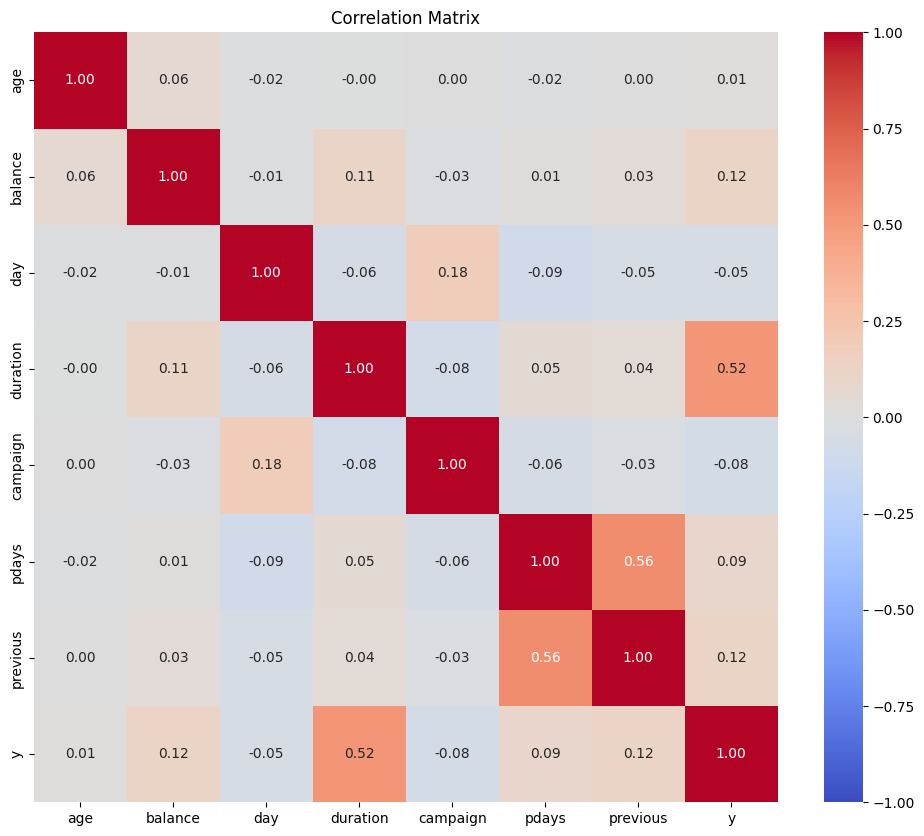

In [13]:
# let's check the correlation between the features and the target variable
numerical_features = [col for col in train.select_dtypes(include=[np.number]).columns]
plt.figure(figsize=(12, 10))
sns.heatmap(train[numerical_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

Some ideas of feataure engineering to help the models:
- for pdays, we can create a new binary feature indicating whether the client was previously contacted or not (pdays = -1), and also create a new feature with the log-transformed pdays for those clients that were previously contacted (pdays > -1).
- we can combine promising features to create new features, such as the interaction between balance and campaign, which could capture the effect of being contacted multiple times for clients with different balance levels.


In [23]:
train_transformed = train.copy()
test_transformed = test.copy()


# for pdays, we can create a new binary feature indicating whether the client was previously contacted or not (pdays = -1), and also create a new feature with the log-transformed pdays for those clients that were previously contacted (pdays > -1).
train_transformed['previously_contacted'] = (train['pdays'] != -1).astype(int)
test_transformed['previously_contacted'] = (test['pdays'] != -1).astype(int)

# it can be useful to combine some features, such as job and education
train_transformed["job_education"] = (
    train_transformed["job"].astype(str) + "_" + train_transformed["education"].astype(str)
)
test_transformed["job_education"] = (
    test_transformed["job"].astype(str) + "_" + test_transformed["education"].astype(str)
)

# mix duration and balance, because they are the two most important features according to the
# correlation matrix, and their interaction might be useful for the model
train_transformed["duration_balance"] = train_transformed["duration"] * train_transformed["balance"]
test_transformed["duration_balance"] = test_transformed["duration"] * test_transformed["balance"]


numerical_features = [col for col in train_transformed.select_dtypes(include=[np.number]).columns if col != 'y']

### Categorical variables

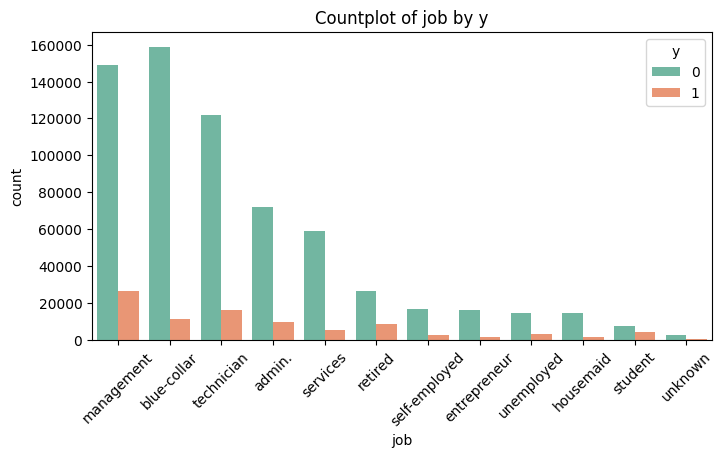

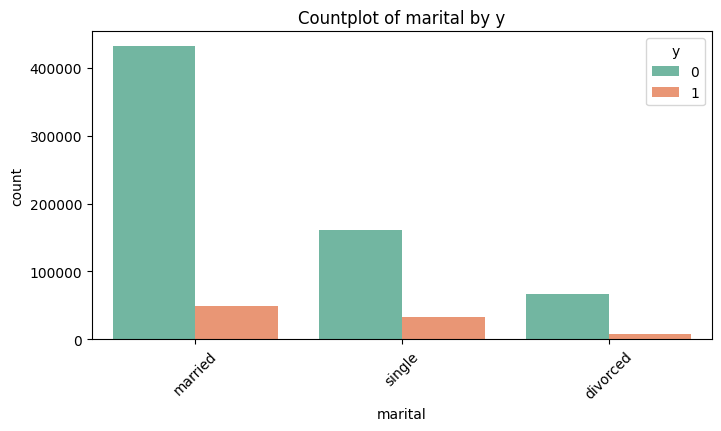

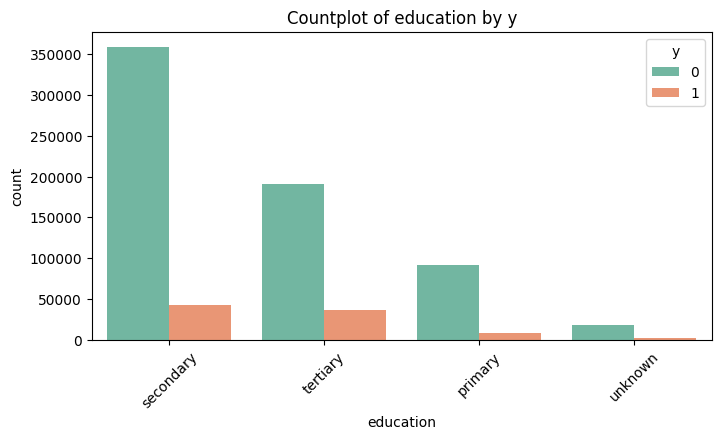

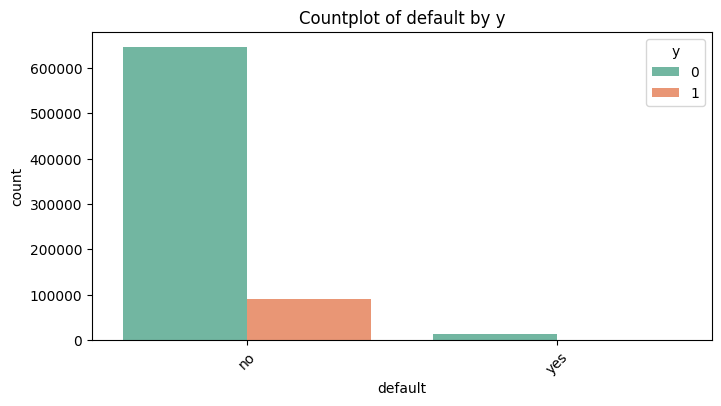

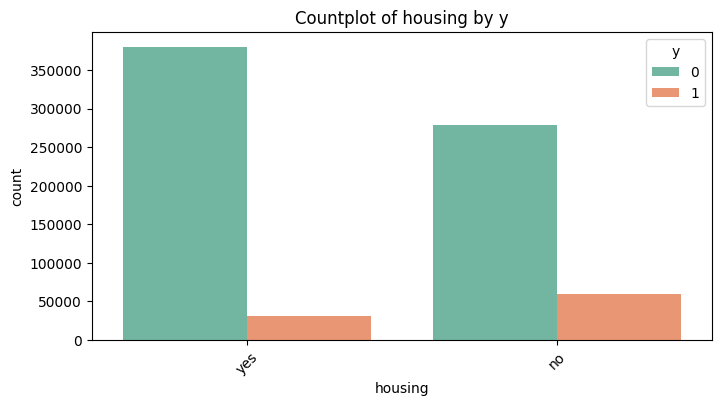

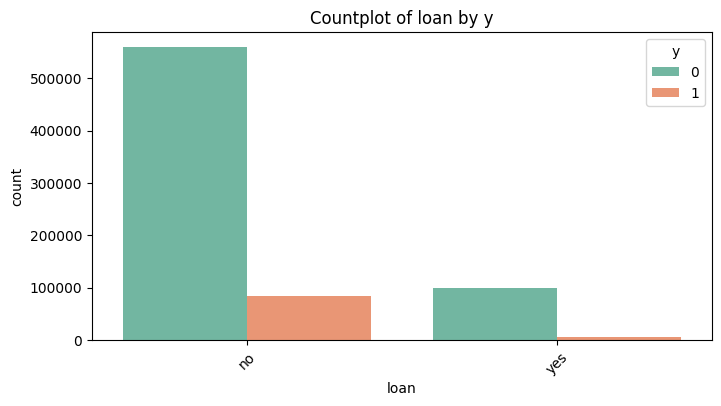

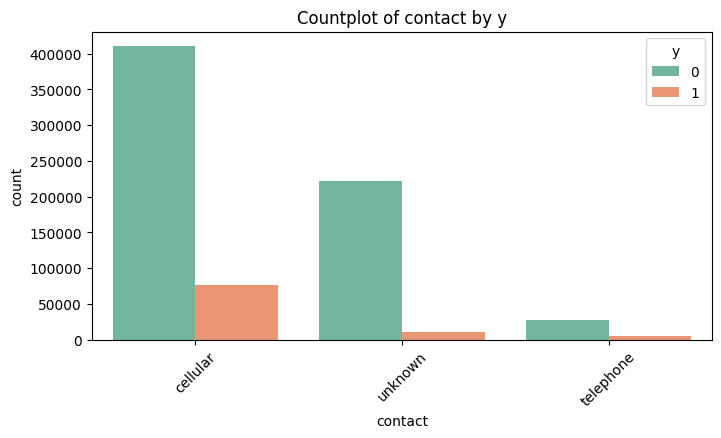

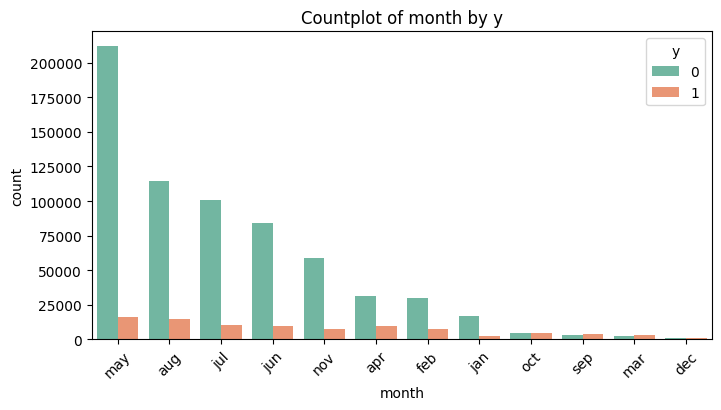

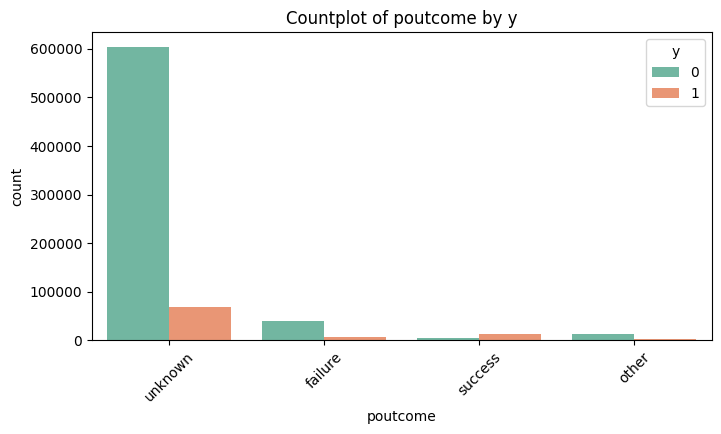

Target variable distribution:
y
0    87.934933
1    12.065067
Name: proportion, dtype: float64


In [11]:
# categorical features
categorical_cols = train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=train,
        x=col,
        order=train[col].value_counts().index,
        hue="y",              # different colors for target classes
        palette="Set2"        # choose any seaborn palette
    )
    plt.title(f'Countplot of {col} by y')
    plt.xticks(rotation=45)
    plt.legend(title="y")
    plt.show()

print("Target variable distribution:")
print(train['y'].value_counts(normalize=True) * 100)

In [12]:
# print, for every categorical variable, and for every value that the variable can assume, the percentage of samples in the train dataset that have that value and belong to class 1 (y=1)
for col in categorical_cols:
    print(f"Percentage of samples with y=1 for each value of {col}:")
    percentages = train.groupby(col)['y'].mean() * 100
    print(percentages)
    print('-------------------------------------')

Percentage of samples with y=1 for each value of job:
job
admin.           11.645315
blue-collar       6.743774
entrepreneur      8.138616
housemaid         8.465309
management       15.039222
retired          24.624130
self-employed    12.944269
services          8.271426
student          34.078355
technician       11.832130
unemployed       17.982307
unknown          12.067192
Name: y, dtype: float64
-------------------------------------
Percentage of samples with y=1 for each value of marital:
marital
divorced    11.157552
married     10.187225
single      17.045280
Name: y, dtype: float64
-------------------------------------
Percentage of samples with y=1 for each value of education:
education
primary       8.309718
secondary    10.549115
tertiary     16.264923
unknown      13.338654
Name: y, dtype: float64
-------------------------------------
Percentage of samples with y=1 for each value of default:
default
no     12.194652
yes     4.630711
Name: y, dtype: float64
--------------

In [13]:
# Encoding categorical variables: let the user choose the method

def encode_categorical(train_df, test_df, method="onehot"):
    # infer categorical columns from the dataframes you pass in (after feature engineering)
    cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

    if method == "label":
        train_encoded = pd.DataFrame(index=train_df.index)
        test_encoded = pd.DataFrame(index=test_df.index)

        for col in cat_cols:
            le = LabelEncoder()
            le.fit(pd.concat([train_df[col], test_df[col]], axis=0))
            train_encoded[col] = le.transform(train_df[col])
            test_encoded[col] = le.transform(test_df[col])

        return train_encoded, test_encoded

    elif method == "onehot":
        train_cats = train_df[cat_cols].copy()
        test_cats = test_df[cat_cols].copy()

        combined = pd.concat([train_cats, test_cats], axis=0)
        combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=False)

        train_encoded = combined_encoded.iloc[: len(train_df), :].copy()
        test_encoded = combined_encoded.iloc[len(train_df) :, :].copy()

        return train_encoded, test_encoded


    elif method == "frequency":
        train_encoded = pd.DataFrame(index=train_df.index)
        test_encoded = pd.DataFrame(index=test_df.index)

        for col in cat_cols:
            freq = pd.concat([train_df[col], test_df[col]], axis=0).value_counts()
            train_encoded[col] = train_df[col].map(freq)
            test_encoded[col] = test_df[col].map(freq)

        return train_encoded, test_encoded

    elif method == "target":
        train_encoded = pd.DataFrame(index=train_df.index)
        test_encoded = pd.DataFrame(index=test_df.index)

        for col in cat_cols:
            target_mean = train_df.groupby(col)['y'].mean()
            train_encoded[col] = train_df[col].map(target_mean)
            test_encoded[col] = test_df[col].map(target_mean)

        return train_encoded, test_encoded

    else:
        raise ValueError("Invalid encoding method. Choose 'label' or 'onehot'.")

### Numerical variables

In [24]:
#we describe the train dataset to get a statistical summary of the numerical features (not the categorical ones!)
numeric_cols = train_transformed.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numeric_cols if col != 'y']
train_transformed[numerical_features].describe()

,age,balance,day,duration,campaign,pdays,previous,previously_contacted,duration_balance
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,7.500000e+05
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.103421,3.932599e+05
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.304509,1.336345e+06
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,-8.917128e+06
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000,0.000000e+00
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000,8.025000e+04
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000,3.239100e+05
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000,1.205648e+08


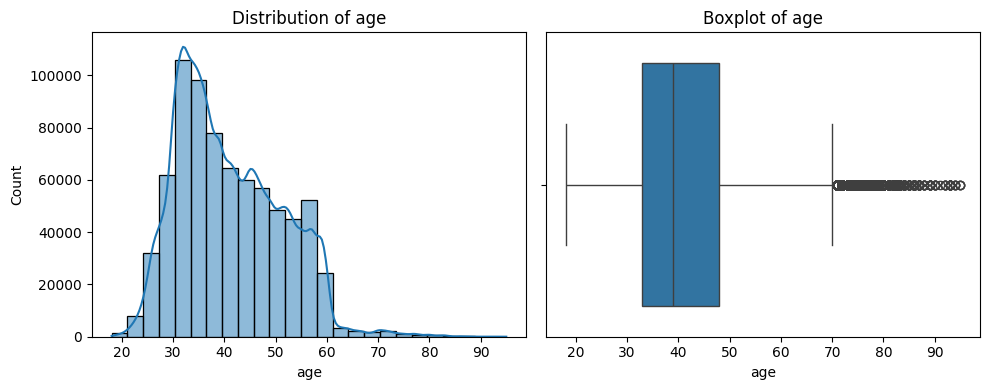

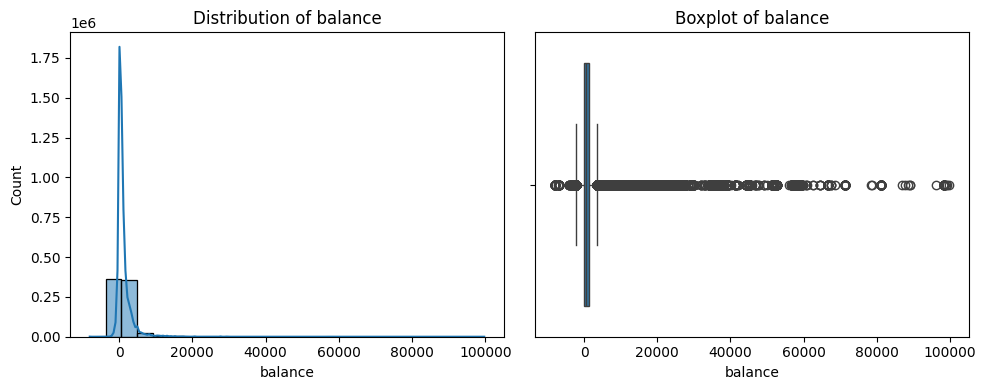

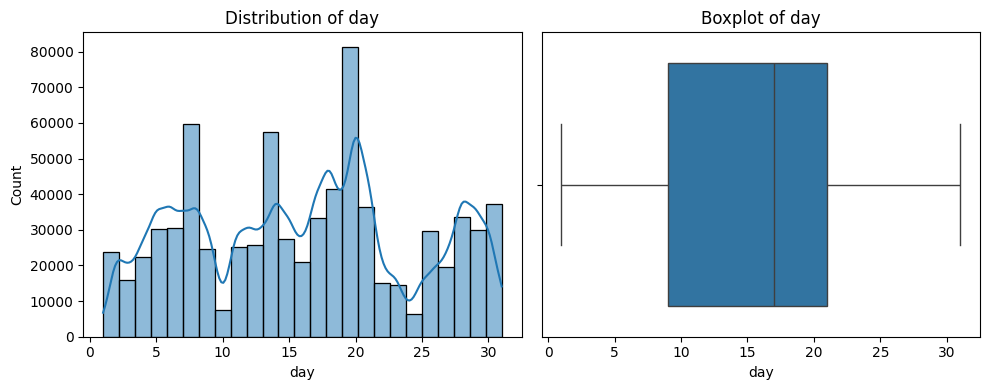

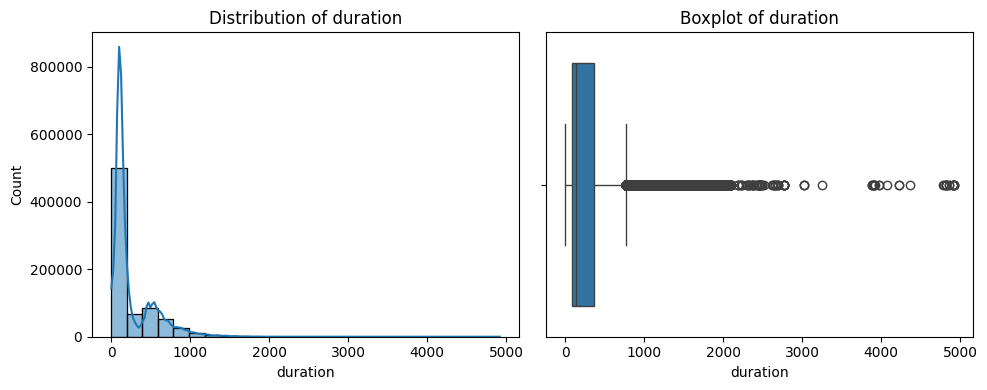

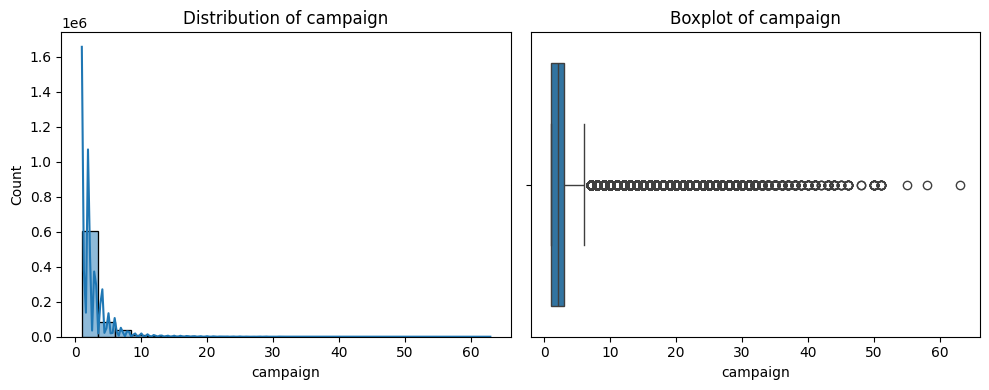

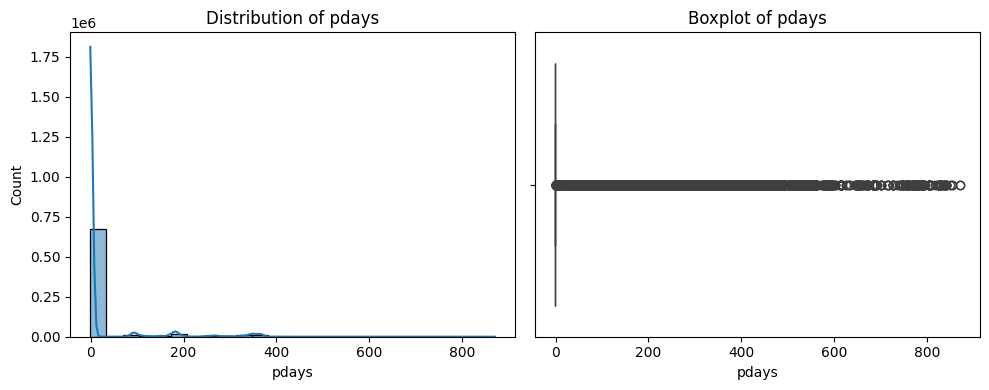

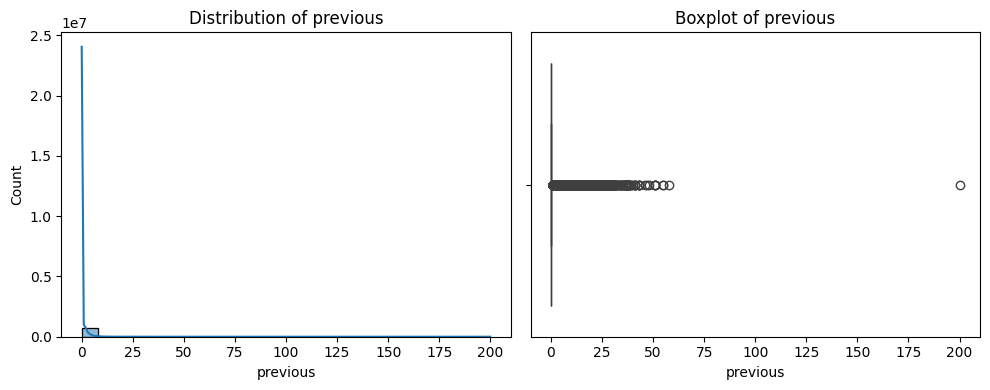

In [ ]:
for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    sns.histplot(train_transformed[col], kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=train_transformed[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


In [25]:
# let's double check skewness of numerical features, that we can also empirically see from the histograms and boxplots
skewness = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print("Skewness of numerical features:")
print(skewness.sort_values(ascending=False))

Skewness of numerical features:
duration_balance        20.506033
previous                13.749885
balance                 12.304123
campaign                 4.810437
pdays                    3.625049
previously_contacted     2.604719
duration                 2.048776
age                      0.586137
day                      0.054014
dtype: float64


Some of the numerical features are highly skewed, such as:
- previous: it makes sense, since most clients were not contacted in previous campaigns, so the distribution is skewed towards zero.
- balance: it is kewed because some clients may have very high balances, while most have little money.
- campaign: it is skewed because most clients may have been contacted only once (which is the minimum value since it also includes last contact), while a few clients may have been contacted many times.
- pdays: it is skewed because most clients were not contacted in previous campaigns (pdays = -1), while a few clients may have been contacted recently (pdays close to zero) or a long time ago (pdays with high positive values).
- duration: it is skewed because most calls may have been short, while a few calls may have been very long.

Since balance can have negative values, we cannot apply a log transformation to it, but we can apply a cube-root transformation, which can handle negative values and also reduce skewness.

In [26]:
skewness = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print(skewness)

age                      0.586137
balance                 12.304123
day                      0.054014
duration                 2.048776
campaign                 4.810437
pdays                    3.625049
previous                13.749885
previously_contacted     2.604719
duration_balance        20.506033
dtype: float64


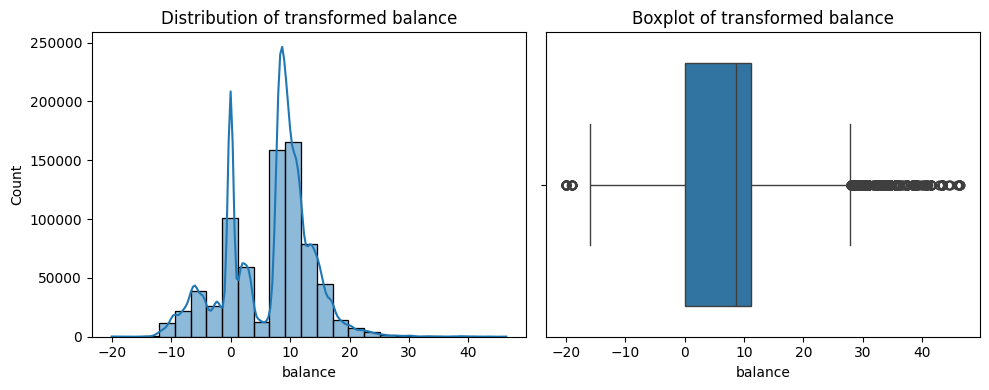

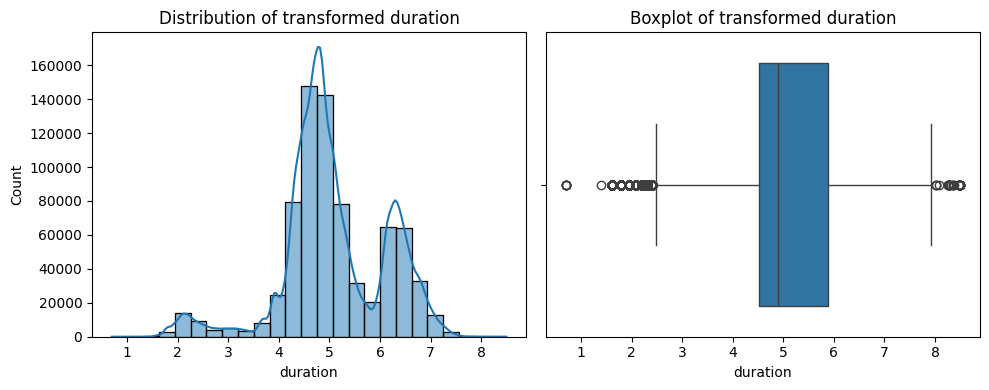

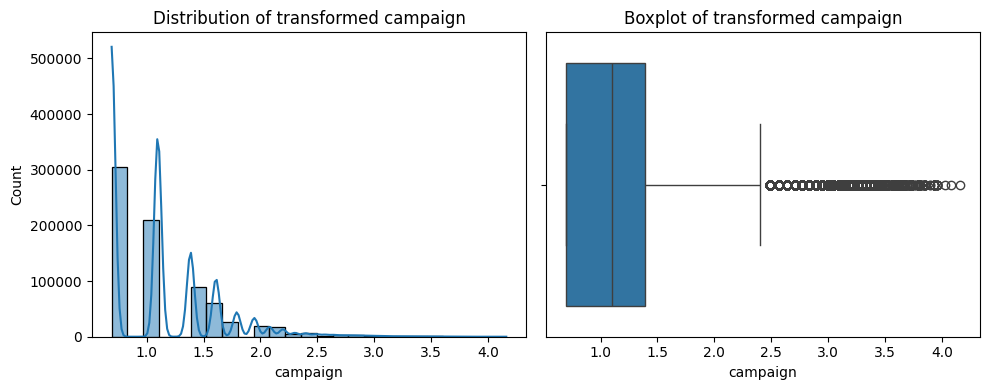

/usr/lib/python3/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


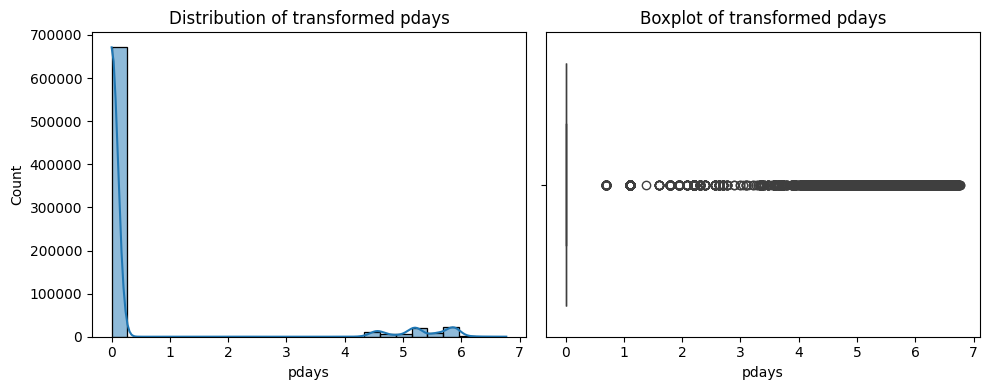

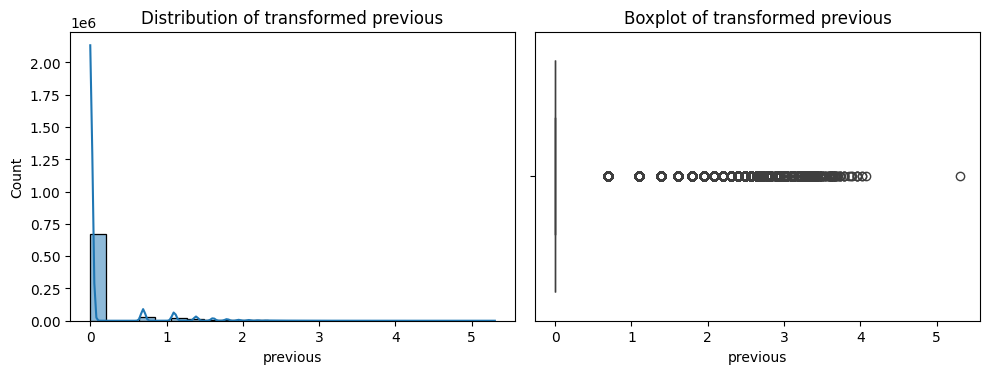

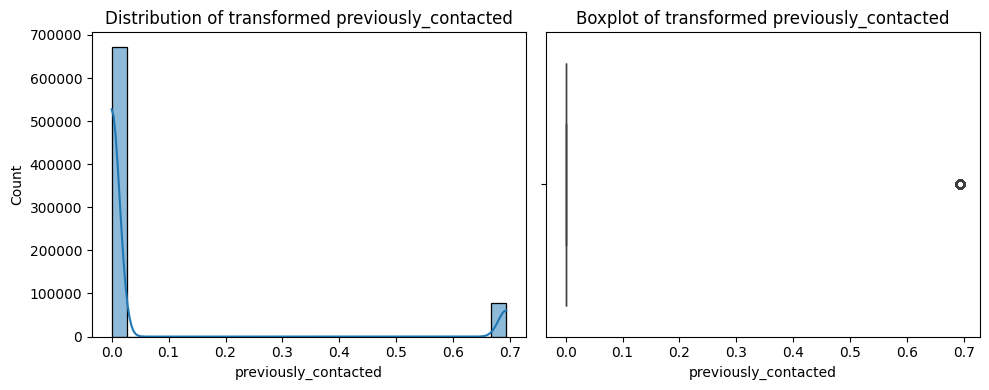

/usr/lib/python3/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


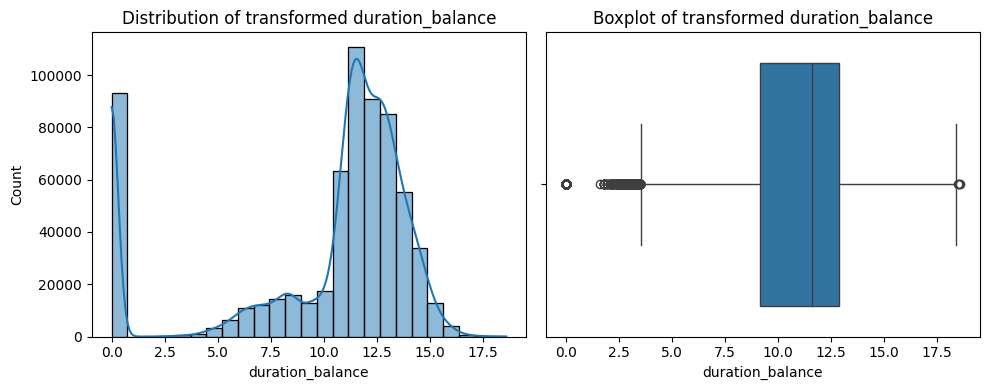

In [27]:
def transform_and_plot_skewed(train_df, test_df, cols, plot=True):
    for col in cols:
        #cube-root transformation for balance, since it can have negative values
        if col == 'balance':  # we apply cube-root transformation only to balance, since it is the most skewed feature and it can have negative values
            train_df[col] = np.cbrt(train_df[col])
            test_df[col] = np.cbrt(test_df[col])
        elif col == 'pdays':
            train_df[col] = np.where(train_df[col] > -1, np.log1p(train_df[col]), 0) # we use np.log1p to handle the case when pdays = 0, since log(0) is undefined. For pdays = -1, we set the log-transformed value to 0 (or any constant), since it indicates that the client was not previously contacted.
            test_df[col] = np.where(test_df[col] > -1, np.log1p(test_df[col]), 0) # we use np.log1p to handle the case when
        else:
            train_df[col] = np.log1p(train_df[col]) # log1p is used to handle the case when the feature can have zero values, since log(0) is undefined
            test_df[col] = np.log1p(test_df[col]) # log1p is used to handle the case when the feature can have zero values, since log(0) is undefined

        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            sns.histplot(train_df[col], kde=True, bins=25, ax=axes[0])
            axes[0].set_title(f'Distribution of transformed {col}')
            sns.boxplot(x=train_df[col], ax=axes[1])
            axes[1].set_title(f'Boxplot of transformed {col}')
            plt.tight_layout()
            plt.show()

skewed_features = skewness[skewness.abs() > 1].index.tolist()

transform_and_plot_skewed(train_transformed, test_transformed, skewed_features, plot=True)

In [28]:
skewness_transformed = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print("Skewness of numerical features (after transformation):")
print(skewness_transformed.sort_values(ascending=False))

Skewness of numerical features (after transformation):
previous                3.619914
pdays                   2.664730
previously_contacted    2.604719
campaign                1.323181
age                     0.586137
day                     0.054014
balance                -0.317423
duration               -0.356506
duration_balance       -1.360047
dtype: float64


In [29]:
def build_encoded_datasets(train_df, test_df, numerical_features, method="label"):
    # encode categoricals (possibly including y) from train_df / test_df
    cat_train_encoded, cat_test_encoded = encode_categorical(
        train_df, test_df, method=method
    )

    y_encoded = train_df["y"]

    # Build final encoded train set: numerical (transformed) + encoded categoricals + target y
    train_encoded = pd.concat(
        [
            train_df[numerical_features],  # numeric only
            cat_train_encoded,             # encoded categoricals (no y)
        ],
        axis=1,
    )
    train_encoded["y"] = y_encoded.values  # single numeric target column

    # Build final encoded test set: numerical (transformed) + encoded categoricals (no y)
    test_encoded = pd.concat(
        [
            test_df[numerical_features],
            cat_test_encoded,
        ],
        axis=1,
    )

    # sanity check: no duplicate columns
    assert not train_encoded.columns.duplicated().any()

    print("Encoded train features:")
    print(train_encoded.columns.tolist())
    print("Number of features:", len(train_encoded.columns))

    return train_encoded, test_encoded


# build default encoded datasets (label encoding) for downstream cells
train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="label"
)


Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20


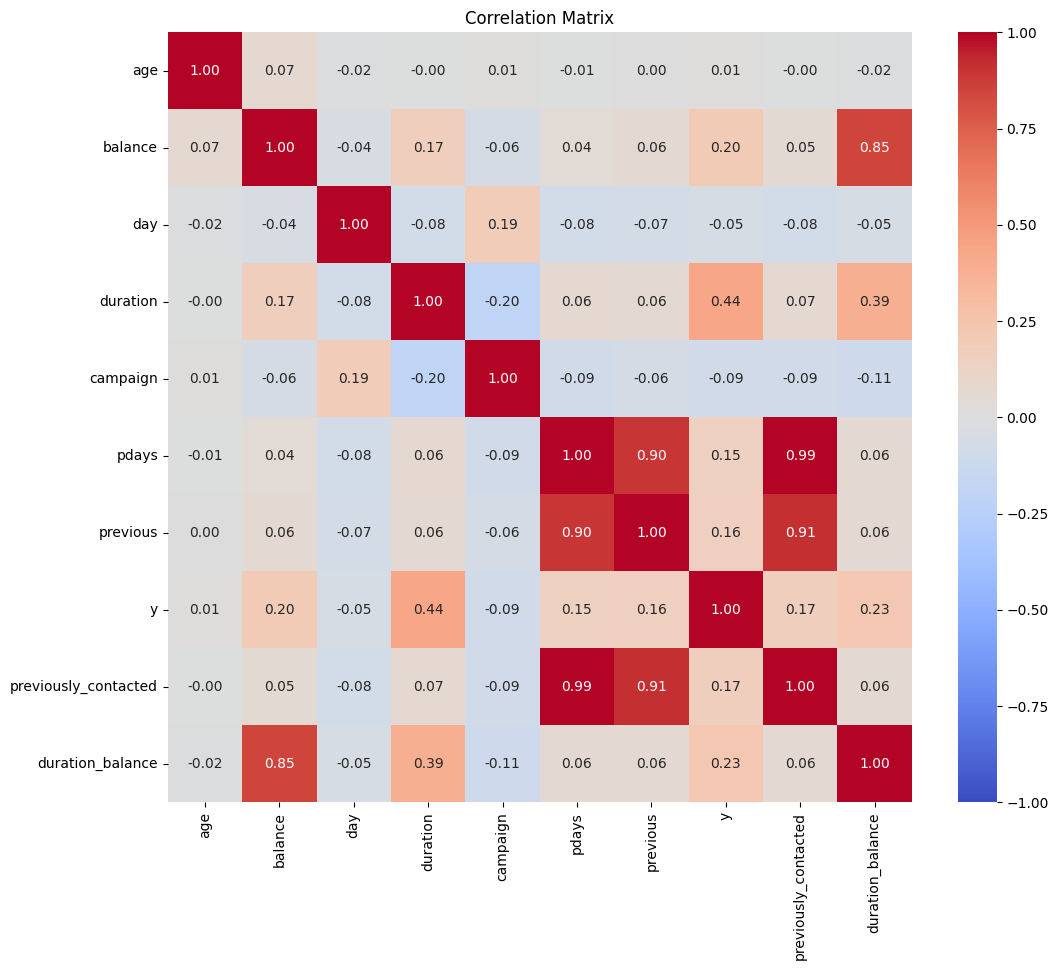

In [32]:
# correlation matrix

numeric_cols = train_transformed.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numeric_cols if col != 'y']

plt.figure(figsize=(12, 10))
sns.heatmap(train_transformed[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# ML MODELS

Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20
AUC ROC score:  0.9606750096347292


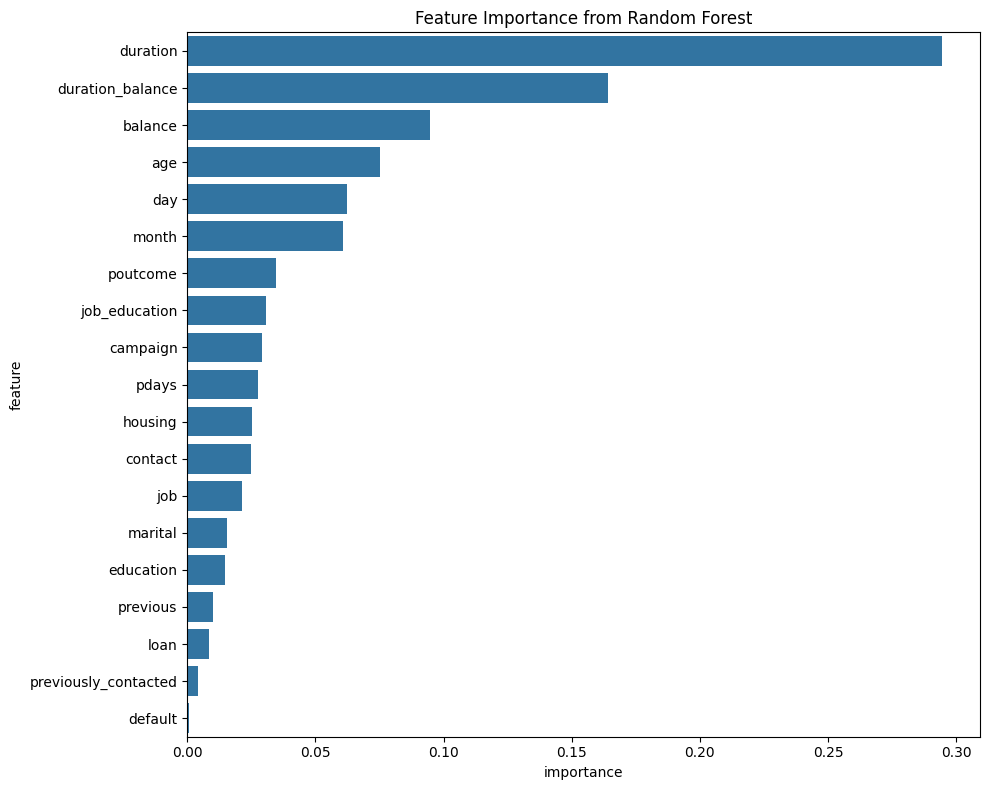

In [33]:
# test a simple random forest to then see feature importanfce

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="label"
)

X = train_encoded.drop("y", axis=1)
y = train_encoded["y"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("AUC ROC score: ", roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1]))

#feature importance plotting
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})

#plot
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=feature_importance_df.sort_values(by="importance", ascending=False))
plt.title("Feature Importance from Random Forest")
plt.tight_layout()
plt.show()


In [31]:
# split train_transformed into X_train and y_train and X_test and y_test

from sklearn.model_selection import train_test_split
X_train = train_encoded.drop('y', axis=1)
y_train = train_encoded['y']
#X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
#print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
#print("y_test shape:", y_test.shape)

X_train shape: (750000, 19)
y_train shape: (750000,)


In [32]:
# simple XGBoost baseline with stratified 10-fold CV and test-time ensembling

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# rebuild encoded datasets with frequency encoding for tree-based models
train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="frequency"
)

X_train = train_encoded.drop('y', axis=1)
y_train = train_encoded['y']

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "booster": "gbtree",

    "max_depth": 7,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_alpha": 0.01,
    "reg_lambda": 1,
    "random_state": 42,
    "n_estimators": 10000,
    "early_stopping_rounds": 100,
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X_train))
xgb_test_fold_predictions = np.zeros((skf.n_splits, test_encoded.shape[0]))
cv_scores = []

print("Training XGBoost with 10-fold stratified cross-validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = XGBClassifier(**xgb_params)
    model.set_params(verbosity=1)  # Set verbosity to 1 for fold-level training output

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=[(X_fold_train, y_fold_train), (X_fold_val, y_fold_val)],  # track AUC on train/val
        verbose=0,
    )

    val_pred = model.predict_proba(X_fold_val)[:, 1]
    oof_predictions[val_idx] = val_pred  # out-of-fold predictions

    # predict on the full test set for this fold
    test_fold_pred = model.predict_proba(test_encoded)[:, 1]
    xgb_test_fold_predictions[fold, :] = test_fold_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# average test predictions across folds (10 versions of Model 1)
xgb_test_pred = xgb_test_fold_predictions.mean(axis=0)

xgb_score = roc_auc_score(y_train, oof_predictions)  # overall OOF score

print("\n" + "=" * 30)
print("XGBoost Results:")
print("CV Scores:", [f"{score:.6f}" for score in cv_scores])
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {xgb_score:.6f}")
print("=" * 30)

# store for later use in a meta-learner / stacking
xgb_oof = oof_predictions.copy()

print("\nXGBoost training completed!")
print(f"Best ROC AUC Score: {xgb_score:.6f}")

Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20
Training XGBoost with 10-fold stratified cross-validation...

Fold 1/10
Fold 1 ROC AUC: 0.969095

Fold 2/10
Fold 2 ROC AUC: 0.967896

Fold 3/10
Fold 3 ROC AUC: 0.966973

Fold 4/10
Fold 4 ROC AUC: 0.967775

Fold 5/10
Fold 5 ROC AUC: 0.967146

Fold 6/10
Fold 6 ROC AUC: 0.967898

Fold 7/10
Fold 7 ROC AUC: 0.968632

Fold 8/10
Fold 8 ROC AUC: 0.968215

Fold 9/10
Fold 9 ROC AUC: 0.968222

Fold 10/10
Fold 10 ROC AUC: 0.967631

XGBoost Results:
CV Scores: ['0.969095', '0.967896', '0.966973', '0.967775', '0.967146', '0.967898', '0.968632', '0.968215', '0.968222', '0.967631']
Mean CV Score: 0.967948 ± 0.000605
Overall OOF Score: 0.967946

XGBoost training completed!
Best ROC AUC Score: 0.967946


In [ ]:
# CatBoost with Stratified 10-Fold CV on RAW (non-encoded) categorical features and test-time ensembling

from catboost import CatBoostClassifier
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

print("=" * 50)
print("MODEL: CatBoost Classifier (Stratified 10-Fold CV, all features as raw categoricals)")
print("=" * 50)

# Use train_transformed directly (it already contains your engineered features)
# target column is 'y'
X_cb = train_transformed.drop("y", axis=1)
y_cb = train_transformed["y"].values

# Build corresponding test set
X_cb_test = test_transformed.copy()

# Convert all columns to string type for CatBoost to treat them as categorical
for col in X_cb.columns:
    X_cb[col] = X_cb[col].astype(str)
    X_cb_test[col] = X_cb_test[col].astype(str)

# All features are now strings, so all are categorical for CatBoost
cat_features = list(range(X_cb.shape[1]))  # Pass all column indices

print("Categorical features passed to CatBoost (all features):", X_cb.columns.tolist())

# Best parameters identified from previous search:
# learning_rate: 0.05, depth: 7
# score: 0.973336

cat_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "learning_rate": 0.05,
    "depth": 7,
    "n_estimators": 10000,  # Max iterations, early stopping will find optimal
    "random_seed": 42,
    "od_wait": 100,   # early stopping rounds
    "verbose": 100,   # print every 100 iterations
    "task_type": "GPU",
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cat_oof_predictions = np.zeros(len(X_cb))
cat_test_fold_predictions = np.zeros((skf.n_splits, X_cb_test.shape[0]))
cat_cv_scores = []

print("Training CatBoost with 10-fold stratified cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cb, y_cb)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_fold_train = X_cb.iloc[train_idx]
    X_fold_val = X_cb.iloc[val_idx]
    y_fold_train = y_cb[train_idx]
    y_fold_val = y_cb[val_idx]

    model = CatBoostClassifier(**cat_params)

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=(X_fold_val, y_fold_val),
        cat_features=cat_features,
        early_stopping_rounds=cat_params["od_wait"],
        use_best_model=True,
        verbose = 0
    )

    val_pred = model.predict_proba(X_fold_val)[:, 1]
    cat_oof_predictions[val_idx] = val_pred

    # predict on the full test set for this fold
    test_fold_pred = model.predict_proba(X_cb_test)[:, 1]
    cat_test_fold_predictions[fold, :] = test_fold_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    cat_cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# average test predictions across folds (10 versions of Model 2)
cat_test_pred = cat_test_fold_predictions.mean(axis=0)

cat_score = roc_auc_score(y_cb, cat_oof_predictions)

print("\n" + "=" * 30)
print("CatBoost Results (Best Parameters):")
print("CV Scores:", [f"{score:.6f}" for score in cat_cv_scores])
print(f"Mean CV Score: {np.mean(cat_cv_scores):.6f} ± {np.std(cat_cv_scores):.6f}")
print(f"Overall OOF Score: {cat_score:.6f}")
print("=" * 30)

# store for later use in a meta-learner / stacking
cat_oof = cat_oof_predictions.copy()

print("\nCatBoost training completed!")
print(f"Final ROC AUC Score: {cat_score:.6f}")

MODEL: CatBoost Classifier (Stratified 10-Fold CV, all features as raw categoricals)
Categorical features passed to CatBoost (all features): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted', 'job_education', 'duration_balance']
Training CatBoost with 10-fold stratified cross-validation...

Fold 1/10


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9440354	best: 0.9440354 (0)	total: 132ms	remaining: 21m 57s
100:	test: 0.9704842	best: 0.9704842 (100)	total: 7.63s	remaining: 12m 27s
200:	test: 0.9726318	best: 0.9726318 (200)	total: 15.1s	remaining: 12m 18s
300:	test: 0.9733008	best: 0.9733008 (300)	total: 22.7s	remaining: 12m 10s
400:	test: 0.9736652	best: 0.9736652 (400)	total: 30.1s	remaining: 12m 1s
500:	test: 0.9738702	best: 0.9738702 (500)	total: 37.5s	remaining: 11m 51s
600:	test: 0.9740344	best: 0.9740353 (599)	total: 45.1s	remaining: 11m 44s
700:	test: 0.9741568	best: 0.9741568 (700)	total: 52.6s	remaining: 11m 37s
800:	test: 0.9743158	best: 0.9743158 (800)	total: 60s	remaining: 11m 28s
900:	test: 0.9744239	best: 0.9744242 (898)	total: 1m 7s	remaining: 11m 23s
1000:	test: 0.9745149	best: 0.9745151 (999)	total: 1m 15s	remaining: 11m 15s
1100:	test: 0.9746018	best: 0.9746020 (1099)	total: 1m 22s	remaining: 11m 9s
1200:	test: 0.9746610	best: 0.9746610 (1200)	total: 1m 30s	remaining: 11m 4s
1300:	test: 0.9747132	best

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9409061	best: 0.9409061 (0)	total: 131ms	remaining: 21m 49s
100:	test: 0.9682536	best: 0.9682536 (100)	total: 7.56s	remaining: 12m 20s
200:	test: 0.9706692	best: 0.9706692 (200)	total: 15s	remaining: 12m 12s
300:	test: 0.9714604	best: 0.9714604 (300)	total: 22.7s	remaining: 12m 12s
400:	test: 0.9718391	best: 0.9718391 (400)	total: 30.2s	remaining: 12m 3s
500:	test: 0.9720910	best: 0.9720910 (500)	total: 37.8s	remaining: 11m 56s
600:	test: 0.9722721	best: 0.9722721 (600)	total: 45.4s	remaining: 11m 49s
700:	test: 0.9724224	best: 0.9724224 (700)	total: 52.9s	remaining: 11m 42s
800:	test: 0.9725578	best: 0.9725578 (800)	total: 1m	remaining: 11m 34s
900:	test: 0.9726508	best: 0.9726508 (900)	total: 1m 8s	remaining: 11m 27s
1000:	test: 0.9727669	best: 0.9727669 (1000)	total: 1m 15s	remaining: 11m 21s
1100:	test: 0.9728330	best: 0.9728330 (1100)	total: 1m 23s	remaining: 11m 13s
1200:	test: 0.9729055	best: 0.9729055 (1200)	total: 1m 30s	remaining: 11m 5s
1300:	test: 0.9729434	best:

...

0:	test: 0.9422959	best: 0.9422959 (0)	total: 132ms	remaining: 22m 3s
100:	test: 0.9688119	best: 0.9688119 (100)	total: 7.71s	remaining: 12m 36s
200:	test: 0.9709280	best: 0.9709280 (200)	total: 15.2s	remaining: 12m 22s
300:	test: 0.9716306	best: 0.9716306 (300)	total: 22.9s	remaining: 12m 17s
400:	test: 0.9719915	best: 0.9719915 (400)	total: 30.4s	remaining: 12m 6s
500:	test: 0.9721978	best: 0.9721978 (500)	total: 37.8s	remaining: 11m 56s
600:	test: 0.9723949	best: 0.9723953 (599)	total: 45.4s	remaining: 11m 49s
700:	test: 0.9725337	best: 0.9725337 (700)	total: 52.9s	remaining: 11m 42s
800:	test: 0.9726447	best: 0.9726447 (800)	total: 1m	remaining: 11m 34s
900:	test: 0.9727478	best: 0.9727493 (899)	total: 1m 8s	remaining: 11m 27s
1000:	test: 0.9728246	best: 0.9728254 (997)	total: 1m 15s	remaining: 11m 19s
1100:	test: 0.9728860	best: 0.9728860 (1100)	total: 1m 23s	remaining: 11m 12s
1200:	test: 0.9729592	best: 0.9729599 (1198)	total: 1m 30s	remaining: 11m 4s
1300:	test: 0.9730222	best:

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9352337	best: 0.9352337 (0)	total: 123ms	remaining: 20m 31s
100:	test: 0.9687564	best: 0.9687564 (100)	total: 7.67s	remaining: 12m 32s
200:	test: 0.9706649	best: 0.9706649 (200)	total: 15s	remaining: 12m 12s
300:	test: 0.9713479	best: 0.9713479 (300)	total: 22.7s	remaining: 12m 11s
400:	test: 0.9716773	best: 0.9716773 (400)	total: 30s	remaining: 11m 58s
500:	test: 0.9719034	best: 0.9719034 (500)	total: 37.5s	remaining: 11m 51s
600:	test: 0.9720846	best: 0.9720846 (600)	total: 45s	remaining: 11m 44s
700:	test: 0.9722152	best: 0.9722155 (699)	total: 52.6s	remaining: 11m 37s
800:	test: 0.9723566	best: 0.9723573 (799)	total: 1m	remaining: 11m 29s
900:	test: 0.9724549	best: 0.9724549 (900)	total: 1m 7s	remaining: 11m 21s
1000:	test: 0.9725409	best: 0.9725409 (1000)	total: 1m 15s	remaining: 11m 14s
1100:	test: 0.9726063	best: 0.9726079 (1096)	total: 1m 22s	remaining: 11m 6s
1200:	test: 0.9726744	best: 0.9726744 (1200)	total: 1m 29s	remaining: 10m 59s
1300:	test: 0.9727414	best: 0.

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9392862	best: 0.9392862 (0)	total: 132ms	remaining: 21m 59s
100:	test: 0.9670292	best: 0.9670292 (100)	total: 7.73s	remaining: 12m 37s
200:	test: 0.9696102	best: 0.9696102 (200)	total: 15.3s	remaining: 12m 25s
300:	test: 0.9704895	best: 0.9704895 (300)	total: 22.9s	remaining: 12m 19s
400:	test: 0.9708858	best: 0.9708858 (400)	total: 30.5s	remaining: 12m 10s
500:	test: 0.9711568	best: 0.9711568 (500)	total: 38s	remaining: 12m
600:	test: 0.9713621	best: 0.9713621 (600)	total: 45.4s	remaining: 11m 49s
700:	test: 0.9715168	best: 0.9715168 (700)	total: 52.7s	remaining: 11m 39s
800:	test: 0.9716673	best: 0.9716675 (798)	total: 1m	remaining: 11m 30s
900:	test: 0.9718060	best: 0.9718068 (899)	total: 1m 7s	remaining: 11m 23s
1000:	test: 0.9719273	best: 0.9719275 (999)	total: 1m 15s	remaining: 11m 15s
1100:	test: 0.9719985	best: 0.9719985 (1100)	total: 1m 22s	remaining: 11m 8s
1200:	test: 0.9720713	best: 0.9720713 (1200)	total: 1m 30s	remaining: 11m 1s
1300:	test: 0.9721267	best: 0.97

In [35]:
%pip install lightgbm;

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# LightGBM with Stratified 10-Fold cross-validation (OOF predictions and test-time ensembling)

from lightgbm import LGBMClassifier
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# rebuild encoded datasets with frequency encoding for tree-based models
train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="frequency"
)

X_train = train_encoded.drop('y', axis=1)
y_train = train_encoded['y']

print("=" * 50)
print("MODEL: LightGBM Classifier (Stratified 10-Fold CV, GPU)")
print("=" * 50)

lgbm_params = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "random_state": 42,
    "device_type": "gpu",   # use GPU if available
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lgbm_oof_predictions = np.zeros(len(X_train))
lgbm_test_fold_predictions = np.zeros((skf.n_splits, test_encoded.shape[0]))
lgbm_cv_scores = []

print("Training LightGBM with 10-fold stratified cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = LGBMClassifier(**lgbm_params)

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        eval_metric="auc",
        callbacks=[],
        verbose=0
    )

    val_pred = model.predict_proba(X_fold_val)[:, 1]
    lgbm_oof_predictions[val_idx] = val_pred

    # predict on the full test set for this fold
    test_fold_pred = model.predict_proba(test_encoded)[:, 1]
    lgbm_test_fold_predictions[fold, :] = test_fold_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    lgbm_cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# average test predictions across folds (10 versions of Model 3)
lgbm_test_pred = lgbm_test_fold_predictions.mean(axis=0)

lgbm_score = roc_auc_score(y_train, lgbm_oof_predictions)

print("\n" + "=" * 30)
print("LightGBM Results:")
print("CV Scores:", [f"{score:.6f}" for score in lgbm_cv_scores])
print(f"Mean CV Score: {np.mean(lgbm_cv_scores):.6f} ± {np.std(lgbm_cv_scores):.6f}")
print(f"Overall OOF Score: {lgbm_score:.6f}")
print("=" * 30)

# store for later use in a meta-learner / stacking
lgbm_oof = lgbm_oof_predictions.copy()

print("\nLightGBM training completed!")
print(f"Best ROC AUC Score: {lgbm_score:.6f}")

Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20
MODEL: LightGBM Classifier (Stratified 10-Fold CV, GPU)
Training LightGBM with 10-fold stratified cross-validation...

Fold 1/10
[LightGBM] [Info] Number of positive: 81440, number of negative: 593560
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1312
[LightGBM] [Info] Number of data points in the train set: 675000, number of used features: 19
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (10.30 MB) transferred to GPU in 0.011489 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120652 -> initscore=-1.986272
[LightGBM] [Info] Start training from score -1.986272
Fold 1 ROC AUC: 0.970119

Fold 2/10
[LightGBM] [Info] Number of positive: 81440, number of negative: 593560
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the train set: 675000, number of used features: 19
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (10.30 MB) transferred to GPU in 0.012369 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFro

In [ ]:
# Meta-learner (stacking) using OOF predictions from XGBoost, CatBoost, LightGBM

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Stack base model OOF predictions as features
# Make sure xgb_oof, cat_oof, lgbm_oof exist from previous cells
Z = np.column_stack([xgb_oof, cat_oof, lgbm_oof])
print("Stacked feature matrix shape (n_samples, n_models):", Z.shape)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_predictions = np.zeros(len(y_train))
meta_cv_scores = []

print("Training meta-learner (Logistic Regression) with 5-fold stratified CV...")

for fold, (train_idx, val_idx) in enumerate(skf.split(Z, y_train)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    Z_fold_train = Z[train_idx]
    Z_fold_val = Z[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    meta_model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=42,
    )

    meta_model.fit(Z_fold_train, y_fold_train)

    val_pred = meta_model.predict_proba(Z_fold_val)[:, 1]
    meta_oof_predictions[val_idx] = val_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    meta_cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

meta_score = roc_auc_score(y_train, meta_oof_predictions)

print("\n" + "=" * 30)
print("Meta-learner (Stacking) Results:")
print("CV Scores:", [f"{score:.6f}" for score in meta_cv_scores])
print(f"Mean CV Score: {np.mean(meta_cv_scores):.6f} ± {np.std(meta_cv_scores):.6f}")
print(f"Overall OOF Score: {meta_score:.6f}")
print("=" * 30)

# Confusion matrix on training (using OOF predictions, threshold 0.5)
y_train_meta_pred = (meta_oof_predictions >= 0.5).astype(int) # convert probabilities to binary predictions using 0.5 threshold
cm_meta = confusion_matrix(y_train, y_train_meta_pred)
print("\nConfusion matrix (meta-learner, OOF predictions):")
print(cm_meta)

print("\nStacking meta-learner training completed!")
print(f"Best ROC AUC Score (meta-learner): {meta_score:.6f}")

# Train final meta-learner on the full training set
meta_model_full = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)
meta_model_full.fit(Z, y_train)

# Build stacked features for the test set using the averaged
# predictions from each base model (10 versions per model)
Z_test = np.column_stack([xgb_test_pred, cat_test_pred, lgbm_test_pred])
print("Stacked TEST feature matrix shape (n_samples, n_models):", Z_test.shape)

# Final test predictions from the meta-learner
test_pred_meta = meta_model_full.predict_proba(Z_test)[:, 1]

Stacked feature matrix shape (n_samples, n_models): (750000, 3)
Training meta-learner (Logistic Regression) with 5-fold stratified CV...

Fold 1/5
Fold 1 ROC AUC: 0.975127

Fold 2/5
Fold 2 ROC AUC: 0.974217

Fold 3/5
Fold 3 ROC AUC: 0.973730

Fold 4/5
Fold 4 ROC AUC: 0.974911

Fold 5/5
Fold 5 ROC AUC: 0.974244

Meta-learner (Stacking) Results:
CV Scores: ['0.975127', '0.974217', '0.973730', '0.974911', '0.974244']
Mean CV Score: 0.974446 ± 0.000507
Overall OOF Score: 0.974379

Stacking meta-learner training completed!
Best ROC AUC Score (meta-learner): 0.974379
Stacked TEST feature matrix shape (n_samples, n_models): (250000, 3)


In [38]:
# prepare the submission using meta-learner predictions on the test set
sub = submission.copy()
sub['y'] = test_pred_meta
sub.to_csv('submission.csv', index=False)
sub.head()

,y
id,
750000,0.015662
750001,0.044145
750002,0.015121
750003,0.015107
750004,0.018525


### SCOREBOARD
The score I obtained is 0.97478, which placed me in the top 14% of the leaderboard.